<a href="https://colab.research.google.com/github/aman-verma02/Network-Security-System/blob/main/Colab-Google/Network_Security_System_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## The notebook is created in such a way that it is easy to understand, debug, flow of code, evaluation visualization.
## if you find anything that can be improved feel free to raise the issue on github i will merge your request


## -------- Thankyou and enjoy learning ---------


## Loading the dataset from the drive ----------------------------------------------------

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/CICIDS_Dataset/cicids_preprocessed.csv'
df = pd.read_csv(file_path)

df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Idle Mean_log,Idle Max_log,Subflow Fwd Bytes_log,Subflow Bwd Bytes_log,slowness_index,iat_cv,byte_asymmetry,pkt_rate_ratio,active_idle_ratio,flag_density
0,48,2,0,4.0,0.0,2,2,2.000000,0.000000,0,...,0.0,0.0,1.609438,0.000000,16.000000,0.000000,0.800000,4.166667e+13,0.0,0.333333
1,260,2,2,72.0,454.0,36,36,36.000000,0.000000,227,...,0.0,0.0,4.290459,6.120297,52.000000,1.712066,-0.724858,1.000000e+00,0.0,0.000000
2,52,1,1,0.0,0.0,0,0,0.000000,0.000000,0,...,0.0,0.0,0.000000,0.000000,17.333333,0.000000,0.000000,1.000000e+00,0.0,0.500000
3,246731,11,7,587.0,5527.0,191,0,53.363636,71.315178,2920,...,0.0,0.0,6.376727,8.617581,12985.842105,2.096671,-0.807850,1.571429e+00,0.0,0.083333
4,6209,5,0,37.0,0.0,37,0,7.400000,16.546903,0,...,0.0,0.0,3.637586,0.000000,1034.833333,1.850571,0.973684,8.052827e+11,0.0,0.166667


In [3]:
print(df.shape)
print(df.columns.tolist())
print(df['Label'].value_counts())

(958613, 101)
['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Average Packet Size

In [4]:
import pandas as pd
import numpy as np

# 1 . Drop infinite and NAN values
df.replace([np.inf, -np.inf], np.nan, inplace = True)
df.dropna(inplace=True)

# 2. Binary Classification : BENIGN = 0 - mean not a attack, all attacks = 1
df['target'] = df['Label'].apply(lambda x : 0 if x == 'BENIGN' else 1)

# 3. Drop original Label column
df.drop(columns = ['Label'], inplace = True)

# 4. Drop duplicates rows
df.drop_duplicates(inplace = True)

# 5. Check result
print("Shape After cleaning", df.shape)
print("Class Distribution ------------------------")
print(df['target'].value_counts())
print("Any nulls remaining: " , df.isnull().sum().sum())



Shape After cleaning (836641, 101)
Class Distribution ------------------------
target
0    499144
1    337497
Name: count, dtype: int64
Any nulls remaining:  0


In [ ]:
df.to_csv('/content/drive/MyDrive/CICIDS_Dataset/cicids_cleaned.csv', index = False)
print("Saved!")

# EDA -----------------------------------------------------------

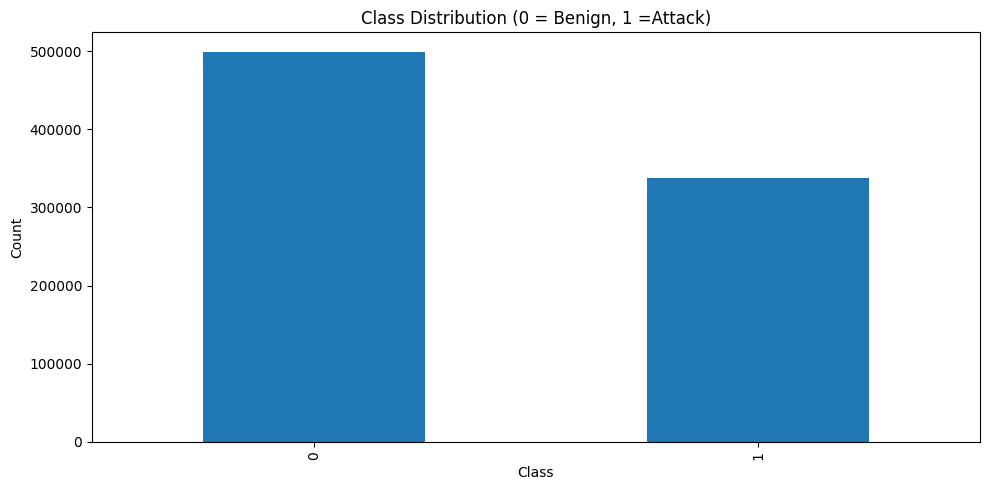

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


## Class Distribution
plt.figure(figsize = (10,5))
df['target'].value_counts().plot(kind = 'bar')
plt.title('Class Distribution (0 = Benign, 1 =Attack)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS_Dataset/class_distribution.png')
plt.show()



In [ ]:
# print(df.describe())
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 836641 entries, 0 to 958612
Columns: 101 entries, Flow Duration to target
dtypes: float64(51), int64(50)
memory usage: 651.1 MB


In [ ]:
df.dtypes
print(df.dtypes.value_counts())

float64    51
int64      50
Name: count, dtype: int64


#### The 'top 20 features' are determined by calculating the absolute correlation of each feature with the target variable and then selecting the 20 features that have the highest absolute correlation values.

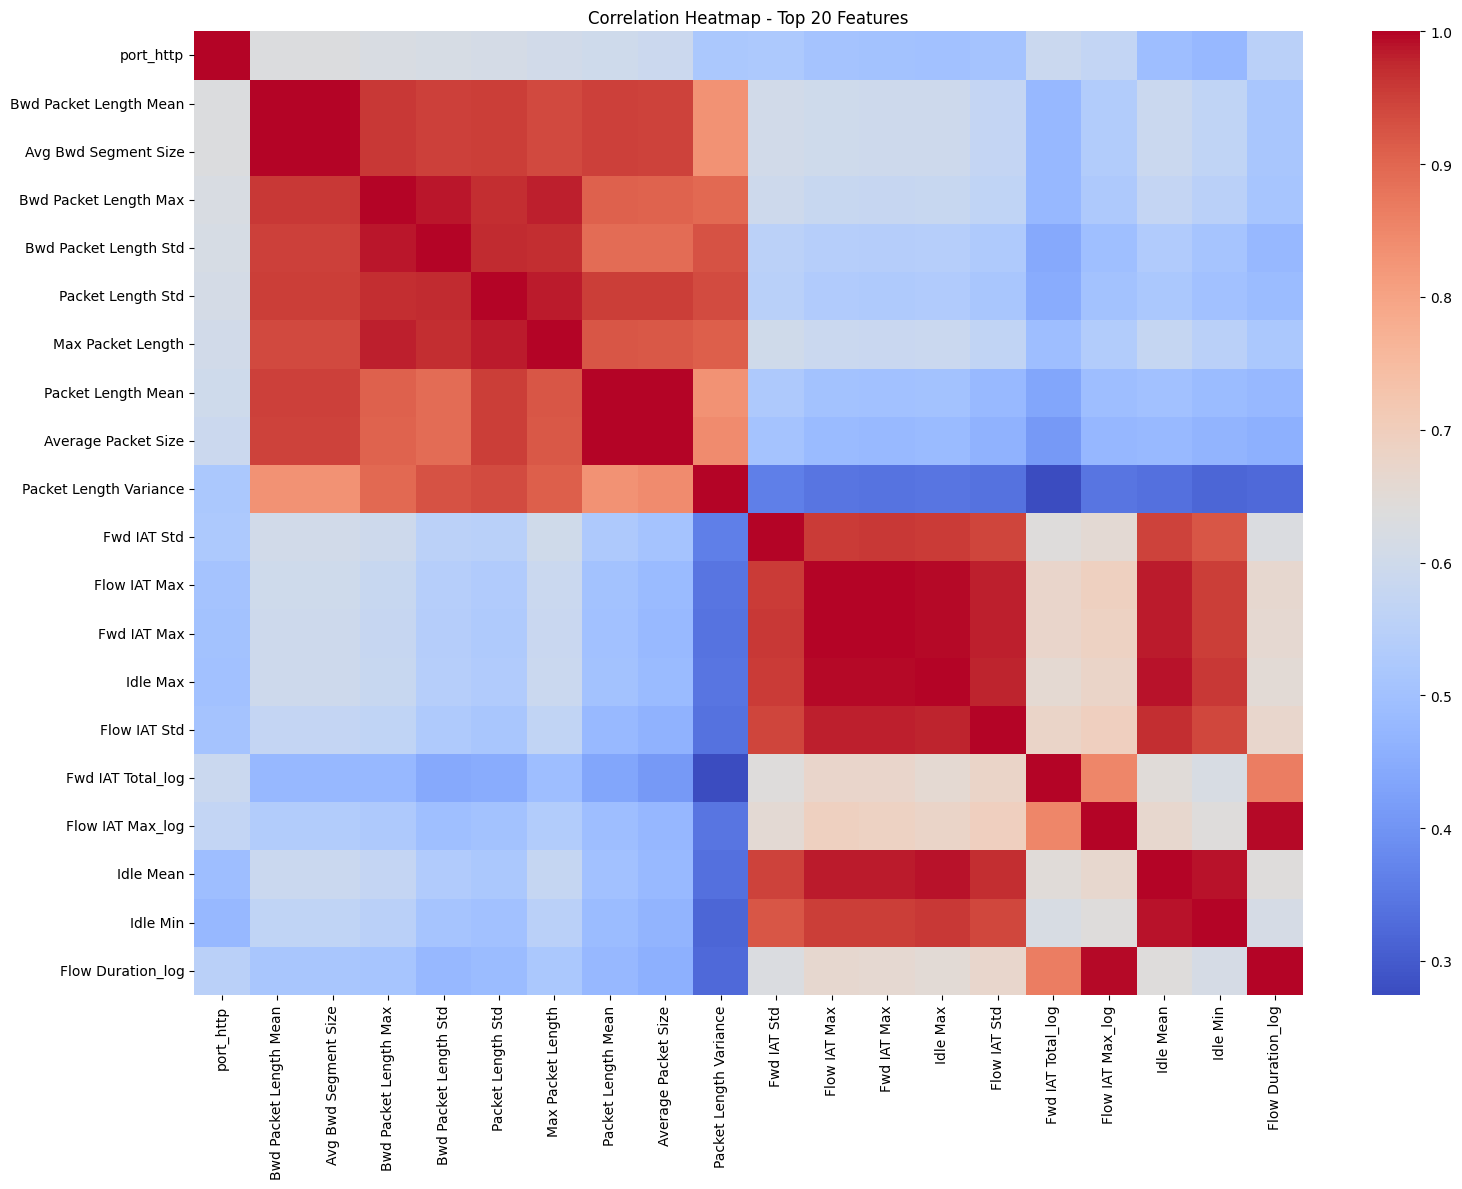

In [ ]:
# Correlation heatmap (top 20 features only, readable)
plt.figure(figsize=(16,12))
top_features = df.drop(columns=['target']).corrwith(df['target']).abs().nlargest(20).index
sns.heatmap(df[top_features].corr(), annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap - Top 20 Features')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS_Dataset/correlation_heatmap.png')
plt.show()



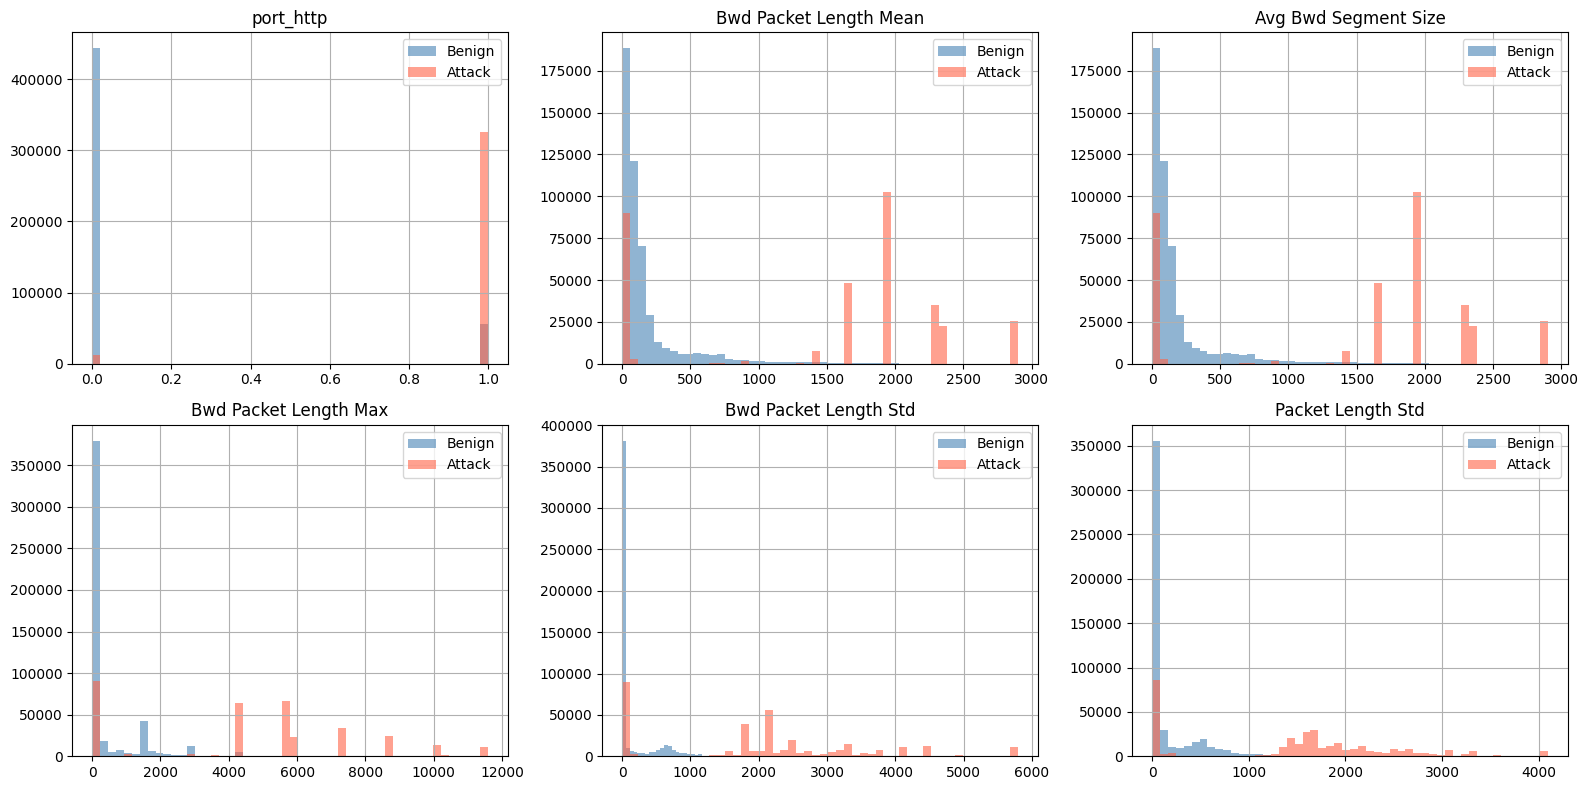

In [ ]:
# Distribution of top 6 features by target correlation
top6 = df.drop(columns=['target']).corrwith(df['target']).abs().nlargest(6).index

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(top6):
    ax = axes[i//3][i%3]
    df[df['target']==0][col].hist(bins=50, alpha=0.6, label='Benign', ax=ax, color='steelblue')
    df[df['target']==1][col].hist(bins=50, alpha=0.6, label='Attack', ax=ax, color='tomato')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS_Dataset/feature_distributions.png')
plt.show()

# Feature Selection ---------------------------------------------------------------

In [ ]:
# 3A — Drop highly correlated features (correlation > 0.95)
corr_matrix = df.drop(columns=['target']).corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
drop_corr = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f"Dropping {len(drop_corr)} highly correlated features:", drop_corr)
df.drop(columns=drop_corr, inplace=True)

Dropping 38 highly correlated features: ['Total Backward Packets', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd Packets/s', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'SYN Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Average Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Fwd Header Length.1', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'act_data_pkt_fwd', 'Idle Mean', 'Idle Max', 'Idle Min', 'Init_Win_bytes_forward_is_zero', 'Flow Packets/s_log', 'Flow IAT Max_log', 'Flow IAT Mean_log', 'Active Max_log', 'Idle Max_log', 'Subflow Fwd Bytes_log', 'Subflow Bwd Bytes_log', 'slowness_index', 'pkt_rate_ratio']


In [ ]:
# 3B — Drop low variance features
from sklearn.feature_selection import VarianceThreshold

X = df.drop(columns=['target'])
y = df['target']

selector = VarianceThreshold(threshold=0.01)
selector.fit(X)
drop_variance = X.columns[~selector.get_support()].tolist()
print(f"Dropping {len(drop_variance)} low variance features:", drop_variance)
X = X[X.columns[selector.get_support()]]

Dropping 5 low variance features: ['Fwd URG Flags', 'RST Flag Count', 'port_ftp', 'port_ssh', 'active_idle_ratio']


##### We drop low variance features because they contribute very little to distinguishing between different data points. If a feature has very low variance, it means its values are almost constant across all observations. In machine learning, such features provide minimal information to the model, as they don't help in separating or classifying instances. Essentially, they add noise or computational overhead without providing predictive power, making them good candidates for removal during feature selection.

### The 'top features' are selected based on their importance as determined by a Random Forest Classifier. Here's how it works:

#### 1. Random Forest Training: A RandomForestClassifier model is trained on a sampled subset of your data (X_sample, y_sample). A Random Forest is an ensemble learning method that builds multiple decision trees during training.
#### 2. Feature Importance Calculation: After the Random Forest is trained, it provides a score for each feature, called feature_importances_. This score quantifies how much each feature contributes to reducing impurity (e.g., Gini impurity or entropy) across all the decision trees in the forest. Features that are frequently used to make important splits in the trees, and lead to a significant reduction in impurity, will have higher importance scores.
#### 3. Ranking and Selection: These importance scores are then ranked, and the nlargest(40) function is used to select the 40 features with the highest importance values. These are considered the 'top' features because the Random Forest model deemed them most influential in predicting the target variable.

In [ ]:
# 3C — Keep top features by Random Forest importance
from sklearn.ensemble import RandomForestClassifier

# Use a small sample just for feature selection (fast)
X_sample = X.sample(n=50000, random_state=42)
y_sample = y[X_sample.index]

rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)

importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.nlargest(40).index.tolist()
print(f"Keeping top {len(top_features)} features")
print(top_features)

X = X[top_features]

Keeping top 40 features
['Packet Length Variance', 'port_http', 'Total Length of Bwd Packets', 'byte_asymmetry', 'Bwd Packet Length Max', 'Total Length of Bwd Packets_log', 'Total Fwd Packets', 'flag_density', 'Fwd IAT Total_log', 'iat_cv', 'Bwd Header Length', 'Fwd Header Length', 'port_https', 'Flow Duration', 'Bwd Packets/s', 'Fwd Packet Length Mean', 'Init_Win_bytes_backward', 'Total Length of Fwd Packets', 'Fwd Packet Length Min', 'Total Length of Fwd Packets_log', 'Init_Win_bytes_forward', 'Flow Bytes/s_log', 'Flow IAT Std', 'Fwd Packet Length Max', 'Fwd IAT Min', 'Bwd Packet Length Min', 'Flow Packets/s', 'Flow IAT Mean', 'Flow Duration_log', 'Bwd IAT Total', 'Bwd IAT Max', 'Active Min', 'Idle Mean_log', 'Flow IAT Min', 'Flow Bytes/s', 'min_seg_size_forward', 'PSH Flag Count', 'Bwd IAT Std', 'Active Max', 'Down/Up Ratio']


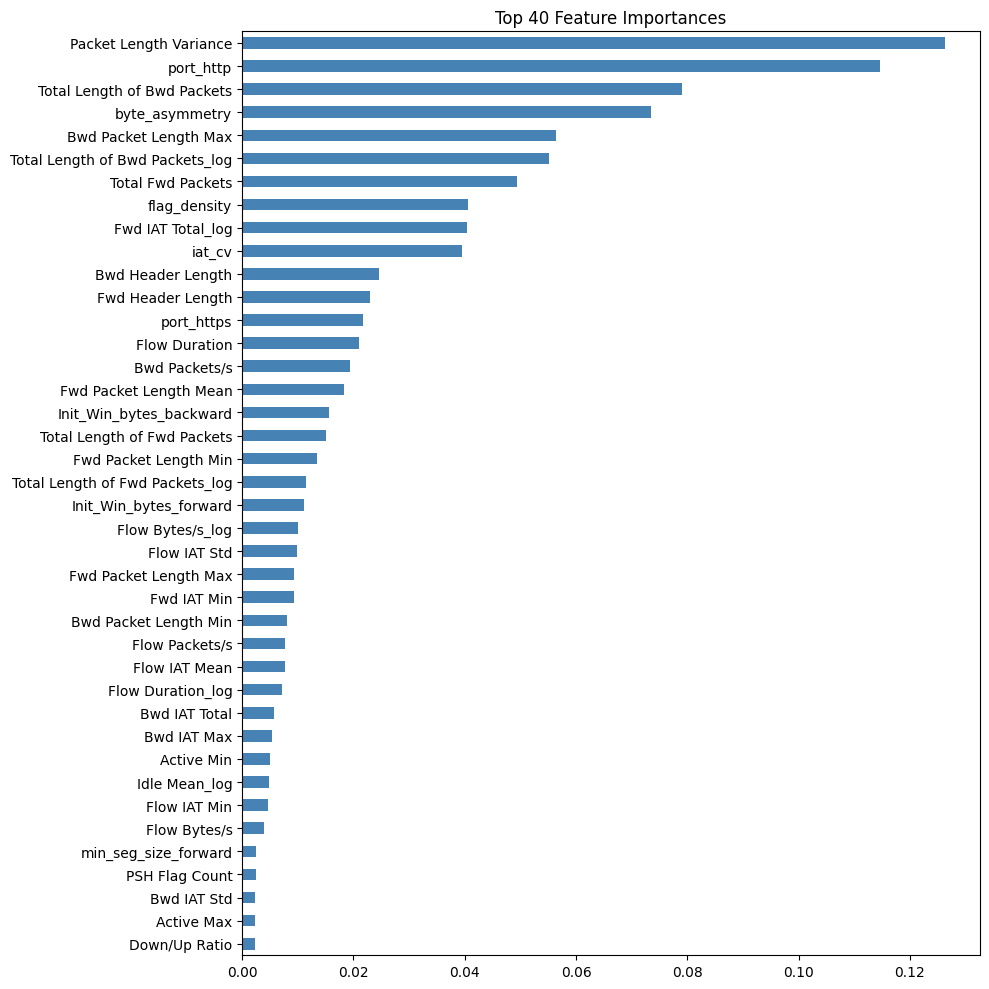

In [ ]:
# Plot feature importances
plt.figure(figsize=(10,10))
importances[top_features].sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 40 Feature Importances')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS_Dataset/feature_importance.png')
plt.show()

# Scaling the feature ---------------------------------

In [ ]:
from sklearn.preprocessing import StandardScaler
import pickle

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=top_features)

print("Scaling done. Shape:", X_scaled.shape)

# Save the scaler as preprocessor
import os
os.makedirs('/content/drive/MyDrive/CICIDS_Dataset/model', exist_ok=True)

with open('/content/drive/MyDrive/CICIDS_Dataset/model/preprocessor.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Also save the selected feature names — you'll need this later
with open('/content/drive/MyDrive/CICIDS_Dataset/model/feature_names.pkl', 'wb') as f:
    pickle.dump(top_features, f)

print("Preprocessor saved!")

Scaling done. Shape: (836641, 40)
Preprocessor saved!


## Train Test Split      ---------------------------------------------

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train class balance:\n", y_train.value_counts())

Train size: (669312, 40)
Test size: (167329, 40)
Train class balance:
 target
0    399315
1    269997
Name: count, dtype: int64


# Balancing the Dataset   --------------------------------

In [ ]:
from imblearn.over_sampling import RandomOverSampler

sampler = RandomOverSampler(random_state=42)
X_train_bal, y_train_bal = sampler.fit_resample(X_train, y_train)

print("Before balancing:", y_train.value_counts().to_dict())
print("After balancing:", pd.Series(y_train_bal).value_counts().to_dict())

Before balancing: {0: 399315, 1: 269997}
After balancing: {1: 399315, 0: 399315}


# Train Multiple. Models ----------------------------------------------

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, accuracy_score)
import time

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'), # Removed tree_method='gpu_hist'
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    start = time.time()

    model.fit(X_train_bal, y_train_bal)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    elapsed = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results[name] = {
        "model": model,
        "accuracy": acc,
        "f1_score": f1,
        "roc_auc": roc,
        "time": elapsed
    }

    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  ROC-AUC  : {roc:.4f}")
    print(f"  Time     : {elapsed:.1f}s")
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Attack']))


Training Random Forest...
  Accuracy : 0.9989
  F1 Score : 0.9986
  ROC-AUC  : 1.0000
  Time     : 212.6s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     99829
      Attack       1.00      1.00      1.00     67500

    accuracy                           1.00    167329
   macro avg       1.00      1.00      1.00    167329
weighted avg       1.00      1.00      1.00    167329


Training Decision Tree...
  Accuracy : 0.9989
  F1 Score : 0.9986
  ROC-AUC  : 0.9990
  Time     : 27.5s
              precision    recall  f1-score   support

      Benign       1.00      1.00      1.00     99829
      Attack       1.00      1.00      1.00     67500

    accuracy                           1.00    167329
   macro avg       1.00      1.00      1.00    167329
weighted avg       1.00      1.00      1.00    167329


Training XGBoost...
  Accuracy : 0.9993
  F1 Score : 0.9991
  ROC-AUC  : 1.0000
  Time     : 15.0s
              precision    recall

# Compare Models --------------------------------


                     Accuracy  F1 Score   ROC-AUC  Train Time (s)
XGBoost              0.999301  0.999134  0.999997            15.0
Random Forest        0.998906  0.998645  0.999961           212.6
Decision Tree        0.998888  0.998622  0.999008            27.5
Logistic Regression  0.969414  0.962558  0.995198             6.0


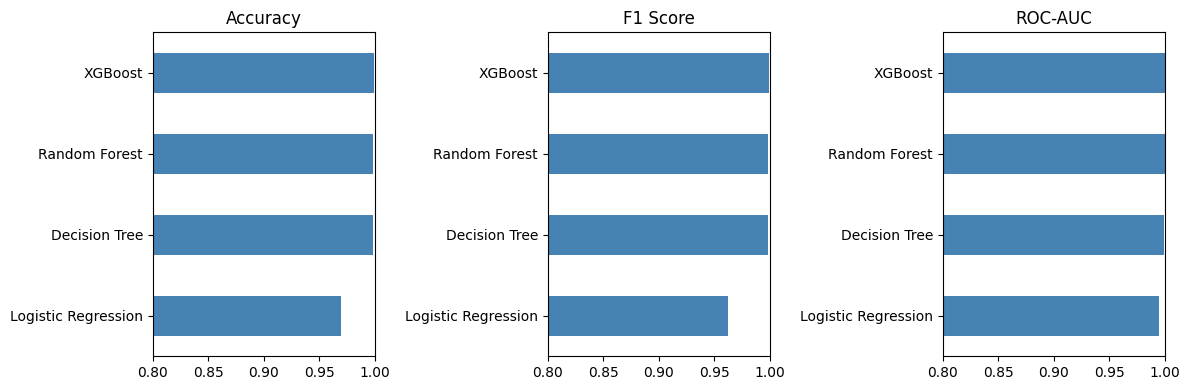

In [ ]:
# Results summary table
results_df = pd.DataFrame({
    name: {
        "Accuracy": v["accuracy"],
        "F1 Score": v["f1_score"],
        "ROC-AUC": v["roc_auc"],
        "Train Time (s)": round(v["time"], 1)
    }
    for name, v in results.items()
}).T

print(results_df.sort_values("F1 Score", ascending=False))

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = ["Accuracy", "F1 Score", "ROC-AUC"]

for i, metric in enumerate(metrics):
    results_df[metric].sort_values().plot(kind='barh', ax=axes[i], color='steelblue')
    axes[i].set_title(metric)
    axes[i].set_xlim(0.8, 1.0)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS_Dataset/plots/model_comparison.png')
plt.show()

# Custom Matrix for best model. -----------------------------------------------

Best model: XGBoost


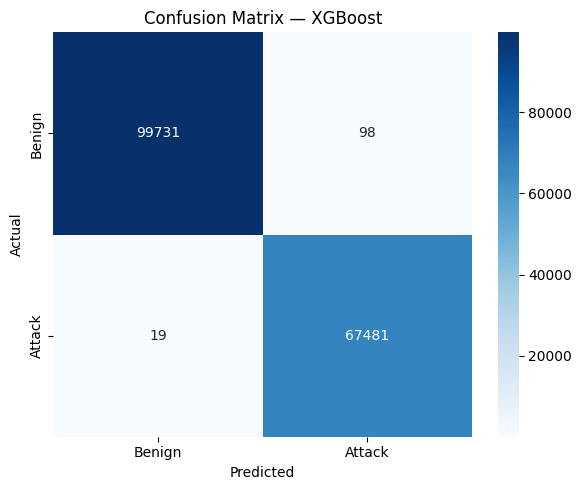

In [ ]:
# Pick best model by F1
best_name = results_df["F1 Score"].idxmax()
best_model = results[best_name]["model"]
print(f"Best model: {best_name}")

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Attack'],
            yticklabels=['Benign','Attack'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/CICIDS_Dataset/plots/confusion_matrix.png')
plt.show()

# Save Best Model and Preprocessor -----------------------------------

In [ ]:
import pickle
import os

os.makedirs('/content/drive/MyDrive/CICIDS_Dataset/model', exist_ok=True)

# Save best model
with open('/content/drive/MyDrive/CICIDS_Dataset/model/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save scaler (already saved earlier, saving again to be safe)
with open('/content/drive/MyDrive/CICIDS_Dataset/model/preprocessor.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names
with open('/content/drive/MyDrive/CICIDS_Dataset/model/feature_names.pkl', 'wb') as f:
    pickle.dump(top_features, f)

# Save results table
results_df.drop(columns=['model'] if 'model' in results_df.columns else []).to_csv(
    '/content/drive/MyDrive/CICIDS_Dataset/model/model_results.csv'
)

print(f"Saved: {best_name}")
print(f"Accuracy : {results[best_name]['accuracy']:.4f}")
print(f"F1 Score : {results[best_name]['f1_score']:.4f}")
print(f"ROC-AUC  : {results[best_name]['roc_auc']:.4f}")

Saved: XGBoost
Accuracy : 0.9993
F1 Score : 0.9991
ROC-AUC  : 1.0000
